# Blending Data from Multiple Sources

This is an example showing how to process data from three data sources. We will be showing how to work with two similar data sets that can be merged, and how to deal with a source that can't be easily merged.

## Introduction to Each Data Source

The first of the two "mergeable" datasets is the surface global irradiance from the Himawari satellite. This data is masked over the ocean away from the coast, and it also has a slightly different grid spacing to the ACCESS model data. 

The second of the two "mergable" datasets is the ACCESS model data, from which we will extract the mean sea level pressure. This is a generally compatible region (lat/lon bounding box), but has a slightly different grid spacing.

The third data set is radar data from one radar in the Australian region. It only has X and Y coordinates, so it's not straightforward to create a simple merged data sets.

In all these examples, a simple linear interpolation is used for merging datasets. More complex merge operations are possible.

```
NCI groups:
  +------------+-------+
  |   Himawari | rv74  |
  |     ACCESS | wr45  |
  |  RadarDemo | rq0   |
  + ===========+=======+
```

### Himawari Data

The tutorial will first introduce a single data set. Datasets can be merged using a pre-defined grid (such as a Mercator projection with a specified grid spacing), or, and this is often simplest, one of the datasets can be used to define the target grid structure without needing a formal specification of it. Let's examine the Himawari data now.

In [1]:
%%capture

import pyearthtools.data as petdata
import pyearthtools.pipeline as petpipe
import tempfile
import site_archive_nci

In [2]:
# We specify the date, hour, and minute for querying data
doi = '2021-06-09T0600'  

In [3]:
himawari = petdata.archive.Himawari('surface_global_irradiance')

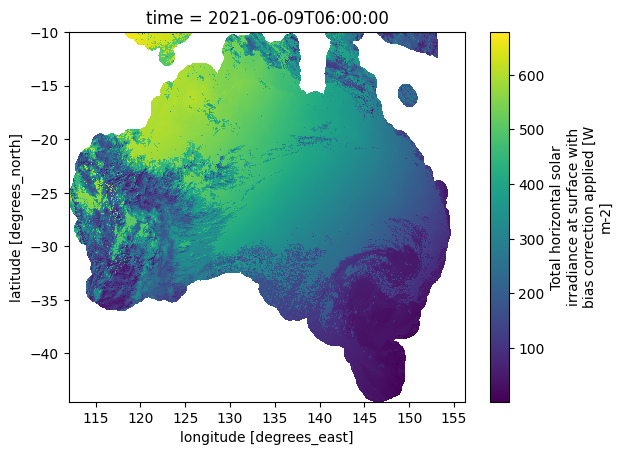

In [4]:
sample_sgi = himawari[doi].surface_global_irradiance
sample_sgi.plot()

In [5]:
# Uncomment the line below to see the data structure
# sample_sgi

### ACCESS Model Data

Here we see how to access a single sample of ACCESS model data

In [6]:
# We want the ACCESS data trimmed to the same bounding box as the Himawari data.
# The ACCESS data is global, but we only want the Australian region
like_himawari = petdata.transform.region.like(sample_sgi) 
access_g = petdata.archive.ACCESS( variables='sfc/mslp', datatype='an', region='g',transforms=like_himawari)

In [7]:
%%capture
sample_mslp = access_g[doi].mslp

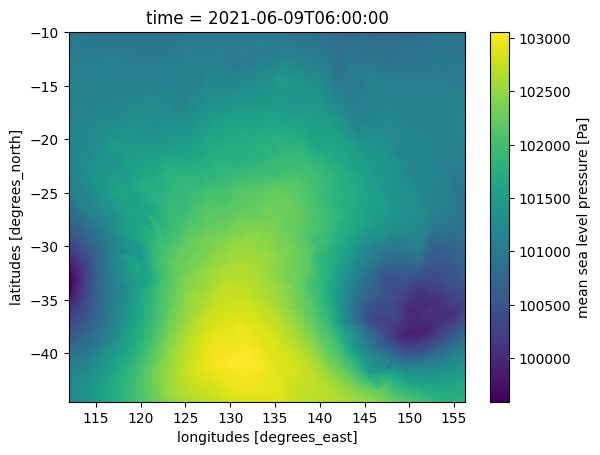

In [8]:
sample_mslp.plot()

### Radar Data

The radar data sample comes from just a single radar, and its geospatial data is not known. We can retrieve samples by date, but it's not easy to geolocate them. Let's examine some data.

In [9]:
radar = petdata.archive.RadarDemo(variables='prcp-crate')

In [10]:
radar_sample = radar[doi]
radar_sample

<xarray.Dataset> Size: 40MB
Dimensions:     (y: 2050, n2: 2, x: 2450)
Coordinates:
  * y           (y) float64 16kB -1.001e+03 -1.003e+03 ... -5.097e+03 -5.099e+03
  * x           (x) float64 20kB -2.299e+03 -2.297e+03 ... 2.597e+03 2.599e+03
Dimensions without coordinates: n2
Data variables:
    valid_time  datetime64[ns] 8B 2021-06-09T06:00:00
    proj        int8 1B 0
    y_bounds    (y, n2) float64 33kB -1e+03 -1.002e+03 ... -5.098e+03 -5.1e+03
    x_bounds    (x, n2) float64 39kB -2.3e+03 -2.298e+03 ... 2.598e+03 2.6e+03
    rain_rate   (y, x) float64 40MB nan nan nan nan nan ... nan nan nan nan nan
Attributes:
    Conventions:         CF-1.7
    contributing_sites:  [ 2  3  4  5  6  8  9 14 15 16 17 19 22 23 24 25 27 ...
    institution:         Commonwealth of Australia, Bureau of Meteorology (AB...
    licence:             http://www.bom.gov.au/other/copyright.shtml
    source:              rainfields 3.2.4 drs-rainfields 2021-02-02
    station_id:          310
    station_name:        Ausm310
    title:               Bias Corrected Rainfall Rate Mosaic

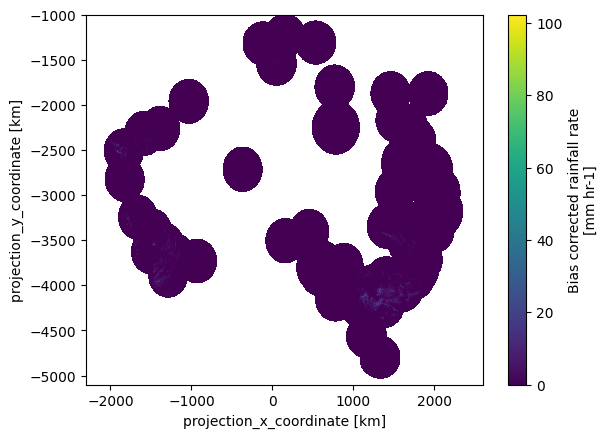

In [11]:
radar_sample.rain_rate.plot()

## Putting them together, the simple way, without "merging" them

Despite their differences, these data sources can easily be co-indexed. If all you want to do is retrieve the relevant samples by date, than can be done quickly and easily using a pipeline.

In [12]:
pipe = petpipe.Pipeline(
    (himawari, access_g, radar),
)
pipe

ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

In [13]:
%%capture
all_sources = pipe[doi]

In [14]:
# Indexing into the pipeline by the data of interest returns a tuple, with
# the retrieved item from each data source according to that data of interest
print(type(all_sources))
print(len(all_sources))

<class 'tuple'>
3


In [15]:
all_sources[2]  # 

<xarray.Dataset> Size: 40MB
Dimensions:     (y: 2050, n2: 2, x: 2450)
Coordinates:
  * y           (y) float64 16kB -1.001e+03 -1.003e+03 ... -5.097e+03 -5.099e+03
  * x           (x) float64 20kB -2.299e+03 -2.297e+03 ... 2.597e+03 2.599e+03
Dimensions without coordinates: n2
Data variables:
    valid_time  datetime64[ns] 8B 2021-06-09T06:00:00
    proj        int8 1B 0
    y_bounds    (y, n2) float64 33kB -1e+03 -1.002e+03 ... -5.098e+03 -5.1e+03
    x_bounds    (x, n2) float64 39kB -2.3e+03 -2.298e+03 ... 2.598e+03 2.6e+03
    rain_rate   (y, x) float64 40MB nan nan nan nan nan ... nan nan nan nan nan
Attributes:
    Conventions:         CF-1.7
    contributing_sites:  [ 2  3  4  5  6  8  9 14 15 16 17 19 22 23 24 25 27 ...
    institution:         Commonwealth of Australia, Bureau of Meteorology (AB...
    licence:             http://www.bom.gov.au/other/copyright.shtml
    source:              rainfields 3.2.4 drs-rainfields 2021-02-02
    station_id:          310
    station_name:        Ausm310
    title:               Bias Corrected Rainfall Rate Mosaic

The coordinates of the radar data are specified as "X" and "Y". Because the radar data has X and Y, we have no way to correlate it with the latitude and longitude dimensions of the Himawari and ACCESS data.

## Merging datasets onto a common grid

(Please note! There is no reason to assume that you want the data on a common grid for machine learning. Many ML algorithms are happy with (and may prefer) unhomogenised data!)

It can be useful to try to merge data sources onto a common grid, so that they all have data at the exact same spots. For example, consider the following data sets:

```
x1=[1,  3,   6,   9, 10],   y1=[1, 9, 36, 81, 100]
x2=[1, 2, 4, 6, 8,   10],   y2=[1, 4, 36, 64, 100]
```

They both fulfil y=x^2, but with slightly different coordinates, but both ranging from 1 to 10 inclusive. The semantics of the ordinal indexing (place value) do not match the semantics of the cadinal indexing (the actual value of the coordinate). It can be really useful to line up two datasets with the same x values. When doing so, it's necessary to guess the corresponding y value in some fashion. In leiu of a clear formula, a linear interpolation of the y values is used.

Either both y1 and y2 could each be interpolated to provide values for, say x=`[1,2,3,4,5,6,7,8,9,10]`, or y1 could be interpolated to give values for the x1 coordinates.

In earth system modelling terms, the most common interpolation is between coordinate reference systems, possibly including different spatial resolutions. "x" in that case is the latitude and longitude values, and "y" would be the data values.

PyEarthTools supports a number of transformations. This notebook demonstrates the "InterpLike" transformation which will map one dataset onto the coordinates of another using linear interpolation.

The first step will be looking at merging Himawari with ACCESS, and then subsequently we will look at how to deal with the fact the radar data cannot be simply merged.

In [16]:
pipe = petpipe.Pipeline(
    (himawari, access_g),
    petpipe.operations.xarray.join.InterpLike(sample_mslp[0])
)
pipe

ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

In [17]:
%%capture
merged_sample = pipe[doi]


In [18]:
merged_sample

<xarray.Dataset> Size: 894kB
Dimensions:                    (time: 1, latitude: 295, longitude: 252)
Coordinates:
  * time                       (time) datetime64[ns] 8B 2021-06-09T06:00:00
  * latitude                   (latitude) float32 1kB -10.02 -10.14 ... -44.47
  * longitude                  (longitude) float32 1kB 112.1 112.2 ... 156.2
Data variables:
    surface_global_irradiance  (time, latitude, longitude) float64 595kB dask.array<chunksize=(1, 295, 252), meta=np.ndarray>
    mslp                       (time, latitude, longitude) float32 297kB dask.array<chunksize=(1, 295, 252), meta=np.ndarray>
Attributes: (12/58)
    Conventions:                      CF-1.7
    Metadata_Conventions:             Unidata Dataset Discovery v1.0
    acknowledgment:                   The following acknowledgement is requir...
    cdm_data_type:                    grid
    comment:                          Solar radiation data derived from satel...
    contributor_name:                 Mines ParisTech; Commonwealth of Austra...
    ...                               ...
    quality:                          0
    quality_meaning:                  0: no_known_issues 1: known_issue 
    project:                          Gridded Solar Observations
    history:                          Mon Mar  4 01:55:13 2024: ncatted -a re...
    references:                       Poulsen C., Majewski L. J. (2022) Gridd...
    NCO:                              netCDF Operators version 4.7.7 (Homepag...

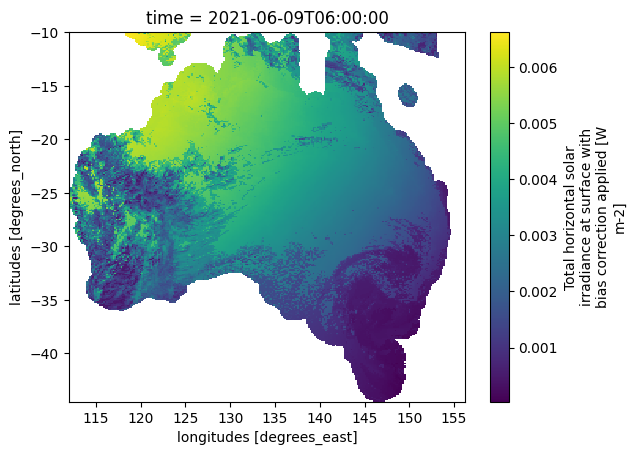

In [19]:
# If we want to, we can now operate on the samples with a common grid
(merged_sample.surface_global_irradiance / merged_sample.mslp).plot()

## Pipelines with Unmergeable Data

In this example, we will merge the Himawari and ACCESS data into a dataset which has a common coordinate reference system, but leave the radar data to be indexed separately. Each request to the pipeline according to the date of interest will return the merged data, together with the relevant unmerged data, as a tuple. The user is then able to interpret each data source as they wish.

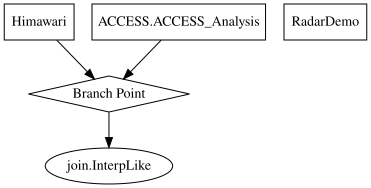

In [20]:
pipe = petpipe.Pipeline(
    (himawari, access_g),
    (petpipe.operations.xarray.join.InterpLike(sample_mslp[0]), radar)
)
pipe

In [21]:
%%capture
sample = pipe[doi]

In [22]:
sample[0]

<xarray.Dataset> Size: 894kB
Dimensions:                    (time: 1, latitude: 295, longitude: 252)
Coordinates:
  * time                       (time) datetime64[ns] 8B 2021-06-09T06:00:00
  * latitude                   (latitude) float32 1kB -10.02 -10.14 ... -44.47
  * longitude                  (longitude) float32 1kB 112.1 112.2 ... 156.2
Data variables:
    surface_global_irradiance  (time, latitude, longitude) float64 595kB dask.array<chunksize=(1, 295, 252), meta=np.ndarray>
    mslp                       (time, latitude, longitude) float32 297kB dask.array<chunksize=(1, 295, 252), meta=np.ndarray>
Attributes: (12/58)
    Conventions:                      CF-1.7
    Metadata_Conventions:             Unidata Dataset Discovery v1.0
    acknowledgment:                   The following acknowledgement is requir...
    cdm_data_type:                    grid
    comment:                          Solar radiation data derived from satel...
    contributor_name:                 Mines ParisTech; Commonwealth of Austra...
    ...                               ...
    quality:                          0
    quality_meaning:                  0: no_known_issues 1: known_issue 
    project:                          Gridded Solar Observations
    history:                          Mon Mar  4 01:55:13 2024: ncatted -a re...
    references:                       Poulsen C., Majewski L. J. (2022) Gridd...
    NCO:                              netCDF Operators version 4.7.7 (Homepag...

In [23]:
sample[1]

<xarray.Dataset> Size: 40MB
Dimensions:     (y: 2050, n2: 2, x: 2450)
Coordinates:
  * y           (y) float64 16kB -1.001e+03 -1.003e+03 ... -5.097e+03 -5.099e+03
  * x           (x) float64 20kB -2.299e+03 -2.297e+03 ... 2.597e+03 2.599e+03
Dimensions without coordinates: n2
Data variables:
    valid_time  datetime64[ns] 8B 2021-06-09T06:00:00
    proj        int8 1B 0
    y_bounds    (y, n2) float64 33kB -1e+03 -1.002e+03 ... -5.098e+03 -5.1e+03
    x_bounds    (x, n2) float64 39kB -2.3e+03 -2.298e+03 ... 2.598e+03 2.6e+03
    rain_rate   (y, x) float64 40MB nan nan nan nan nan ... nan nan nan nan nan
Attributes:
    Conventions:         CF-1.7
    contributing_sites:  [ 2  3  4  5  6  8  9 14 15 16 17 19 22 23 24 25 27 ...
    institution:         Commonwealth of Australia, Bureau of Meteorology (AB...
    licence:             http://www.bom.gov.au/other/copyright.shtml
    source:              rainfields 3.2.4 drs-rainfields 2021-02-02
    station_id:          310
    station_name:        Ausm310
    title:               Bias Corrected Rainfall Rate Mosaic

## Radar: Projection to latlon (EXPERIMENTAL)

The radar accessor now has a new initialiser `RadarDemo.init_with_latlonproj`. As the name suggests, this injects methods in the `RadarDemo` class that perform latlon projections to loaded datasets.

It uses a internal helper for now (`site_archive_nci._RadarDemo.RadarProj`), which may be migrated to PET in the future.

only ALBERS_CONICAL_EQUAL_AREA (+proj=aea) is currently supported, but it is trivial to add more as projection is typically inferred from the underlying dataset anyway. Here "supported" means that it has been "tested" and has approriate "checks" in the code (currently it just checks that it has a inverse).

Dependencies:
- `pyproj` and associated `proj` (or equivilent) backend.
- `scipy` for interpolation - only relevant if `interp_lonlat=True` - see configuration options below

### Configuration options/arguments

`init_with_latlonproj` takes optional keyword args that can be passed to the internal projection algorithms. This is dumped below:  
_(note that the API is EXPERIMENTAL and hence subject to change)_

<details>
    
<pre><code>
  force_proj:
      By default proj is inferred from `ds` (`force_proj=None`);
      if `force_proj` _is not_ None, it will force all projections to use
      that.  Setting `force_proj` supersedes the following settings, which
      will no longer have any effect:
          * `proj_cache`
          * `warn_on_different_proj`
      default: None

  interp_lonlat:
      Whether to use the provided lonlat_meshgrid to perform forward projection 
      and interpolation instead of projection inversion using x-y;
      default: False

  lonlat_meshgrid:
      the lonlat grid to interpolate to, must be a result from a call to
      `np.meshgrid` with appropriate lonlat extents - handled by caller.  Must
      NOT be `None` if `interp_lonlat=True`;
      default: None

  proj_cache:
      Cache containing projections during the lifetime of the caller.  This
      object is managed by the caller/application.  Ideally we should only
      have one projection per data collection.
          * None       => no caching happens
          * Some(list) => list should be initialized/provided by Caller
                          and is mutated with observed projections.
      default: None

  warn_on_different_proj:
      Whether to warn if a new projection is detected that is different from
      what's in `proj_cache` (except when its empty).
      default: False
</code></pre>

</details>


### Assumptions

**general assumptions**

<details>
    <p>
<li> EXPERIMENTAL (i.e. this namespace is tested but not widely used yet).
<li> x-y coordinates are in kilometers (km).
<li> lat-lon coordinates are in degrees (°).
<li> any phyiscal bounds checks are offloaded to underlying pyproj libraries,
  it is the caller's responsibility to manage these.
<li> only ALBERS_CONICAL_EQUAL_AREA is tested so far.
    </p>
</details>
<br>

**assumptions if using interpolation**

<details>
<li> if interp_lonlat=True, interpolation fill NaNs in points where the projection
  of lonlat_meshgrid exceeds the converted x-y coordinate bounds. This
  inherited from scipy and is intentionally not handled here.
<li> however, within a multiple of the max x-y grid spacing
  (MAX_XY_EXTRAPOLATE_GRIDSIZE_MULT) away from the x-y boundaries interp, is
  allowed this is to make allowance for extrapolation. This is to address a)
  rounding issues and b) preserve the non-NaN grid values e.g. if the same grid
  sizes are requried for x-y and lat-lon.
  see: scipy documentation to determine which methods allow for extrapolation.
<li> if explicit extrapolation is required, this should be done elsewhere.
<li> only rectilinear (rectangular with even/uneven spacing) x-y datasets
  are supported for interpolation.
<li> interp doesn't attempt to preserve NaN values for simplicity reasons.
</details>

### Method 1. inverse projection

Here x-y coordinates are inverted into latlon and added back to the dataset.
- This method is usually faster than the interpolation alternative
- It does require that the projection used has an inverse (which may not always be true)

In [24]:
# imports repeated here for convenience reasons

import pyearthtools.data as petdata
import pyearthtools.pipeline as petpipe
import tempfile
import site_archive_nci

# We specify the date, hour, and minute for querying data
doi = '2021-06-09T0600'

<xarray.Dataset> Size: 121MB
Dimensions:     (y: 2050, n2: 2, x: 2450)
Coordinates:
  * y           (y) float64 16kB -1.001e+03 -1.003e+03 ... -5.097e+03 -5.099e+03
  * x           (x) float64 20kB -2.299e+03 -2.297e+03 ... 2.597e+03 2.599e+03
    longitude   (y, x) float64 40MB 111.8 111.9 111.9 ... 163.4 163.4 163.4
    latitude    (y, x) float64 40MB -7.861 -7.864 -7.867 ... -43.73 -43.73
Dimensions without coordinates: n2
Data variables:
    valid_time  datetime64[ns] 8B 2021-06-09T06:00:00
    proj        int8 1B 0
    y_bounds    (y, n2) float64 33kB -1e+03 -1.002e+03 ... -5.098e+03 -5.1e+03
    x_bounds    (x, n2) float64 39kB -2.3e+03 -2.298e+03 ... 2.598e+03 2.6e+03
    rain_rate   (y, x) float64 40MB nan nan nan nan nan ... nan nan nan nan nan
Attributes:
    Conventions:         CF-1.7
    contributing_sites:  [ 2  3  4  5  6  8  9 14 15 16 17 19 22 23 24 25 27 ...
    institution:         Commonwealth of Australia, Bureau of Meteorology (AB...
    licence:             http://www.bom.gov.au/other/copyright.shtml
    source:              rainfields 3.2.4 drs-rainfields 2021-02-02
    station_id:          310
    station_name:        Ausm310
    title:               Bias Corrected Rainfall Rate Mosaic

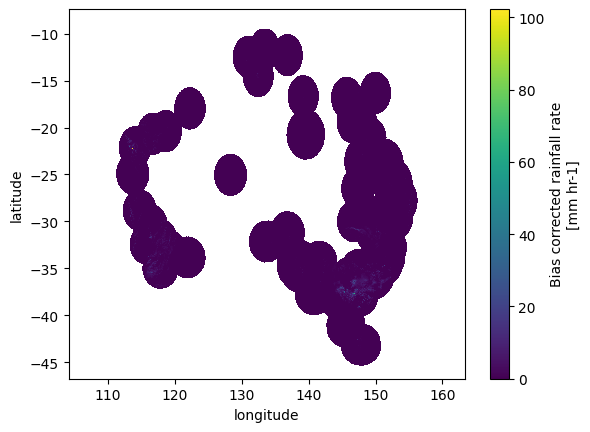

In [25]:
rd_inverse = petdata.archive.RadarDemo.init_with_lonlatproj("prcp-crate")
radar_sample = rd_inverse[doi]
display(radar_sample)
radar_sample.rain_rate.plot(x="longitude", y="latitude")

### Method 2. forward projection with interpolation

Here a latlon meshgrid is provided, x-y coordinates are inverted into latlon and added back to the dataset.
- Interpolation requires scipy as a dependency.
- The user has to provide their own meshgrid, `site_archive_nci._RadarDemo` has a helper to do this, but it is essentially a wrapper around `np.meshgrid`, which the user can choose to use directly.
- The meshgrid is projected internally into x-y and then interpolation is performed in the x-y system
- The 1-D coords of the mesh (in this case lon/lat) are inserted back into the dataset.
- By default the interp method is linear (which also incidentally doesn't mandate the use of scipy)
- This method is also compatible with projections that do not have a direct inverse.

'mesh shapes similar: '

(295, 252)

(295, 252)

<xarray.Dataset> Size: 4MB
Dimensions:     (longitude: 252, latitude: 295, n2: 2)
Coordinates:
    x           (longitude, latitude) float64 595kB -2.239e+03 ... 1.993e+03
    y           (longitude, latitude) float64 595kB -1.225e+03 ... -5.047e+03
  * longitude   (longitude) float32 1kB 112.1 112.2 112.4 ... 155.8 156.0 156.2
  * latitude    (latitude) float32 1kB -10.02 -10.14 -10.25 ... -44.36 -44.47
Dimensions without coordinates: n2
Data variables:
    valid_time  datetime64[ns] 8B 2021-06-09T06:00:00
    proj        int8 1B 0
    y_bounds    (longitude, latitude, n2) float64 1MB -1.224e+03 ... -5.048e+03
    x_bounds    (longitude, latitude, n2) float64 1MB -2.24e+03 ... 1.994e+03
    rain_rate   (longitude, latitude) float64 595kB nan nan nan ... nan nan nan
Attributes:
    Conventions:         CF-1.7
    contributing_sites:  [ 2  3  4  5  6  8  9 14 15 16 17 19 22 23 24 25 27 ...
    institution:         Commonwealth of Australia, Bureau of Meteorology (AB...
    licence:             http://www.bom.gov.au/other/copyright.shtml
    source:              rainfields 3.2.4 drs-rainfields 2021-02-02
    station_id:          310
    station_name:        Ausm310
    title:               Bias Corrected Rainfall Rate Mosaic

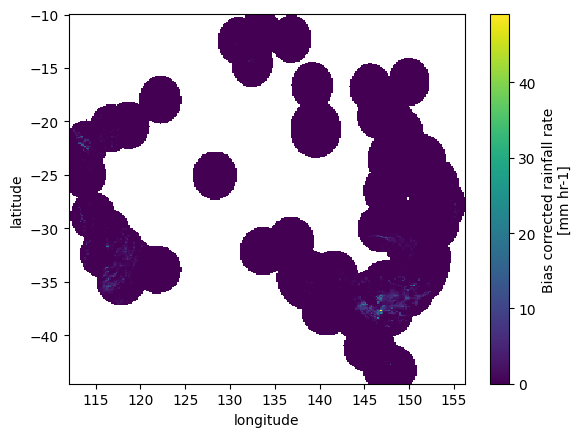

In [26]:
import numpy as np

# NOTE: setting up for interpolation is slightly more complex than performing an inverse proj.
#     - There are benefits to using interpolation rather than inverse which will be illustrated at a later tutorial.
#     - The main one being that the lat-lon grids can be defined rectilinear, whereas with inverse we get a 2-D grid back for each lat/lon coord

# ---
# 1. the user needs to specify a lonlat grid - this cannot be inferred (otherwise we're better off just doing an inverse)
# ---
ref_ds = sample_mslp[0]

# 1a. we can make the meshgrid directly - since lon/lat are already 1-D vectors
mg_lonlat = np.meshgrid(ref_ds.longitude.values, ref_ds.latitude.values)

# 1b. alternatively, this is a convenience helper in case we don't have a reference dataset.
#     note: this is a contrived example compared to 1b. because we already have a reference we'd like to match.
minmax_lon = (np.min(ref_ds.longitude.values), np.max(ref_ds.longitude.values))
minmax_lat = (np.min(ref_ds.latitude.values), np.max(ref_ds.latitude.values))

_unused_mg_lonlat = site_archive_nci._RadarDemo.RadarProj.make_lonlat_meshgrid(
    lon_extent=minmax_lon,
    num_lon=len(ref_ds.longitude),
    lat_extent=minmax_lat,
    num_lat=len(ref_ds.latitude),
    endpoint=True
)

# just double checking that they are indeed similar
display("mesh shapes similar: ", _unused_mg_lonlat[0].shape, mg_lonlat[1].shape)

# ---
# 2. as before call `init_with_lonlatproj` but this time
# ---
rd_interp = petdata.archive.RadarDemo.init_with_lonlatproj(
    "prcp-crate",
    proj_kwargs={
        "interp_lonlat": True,
        "lonlat_meshgrid": mg_lonlat,  # required
        "interp_method": "linear",     # optional but being explicit, linear is the default
    },
)
radar_sample = rd_interp[doi]
display(radar_sample)
radar_sample.rain_rate.plot(y="latitude", x="longitude")

### Advanced

The following go through additional kwargs that can be specified to `init_with_latlonproj`. These typically would not be needed, but an advanced user may want to take note of them.

#### checking for projection consistency, using caching

The code doesn't assume responsibility of having consistent projections - since inconsistant projections in the same collection of data may still be valid. However, there are options that can be specified to alert the user if such scenarios arise...

TODO: details
    
#### interpolation strategies

For the most part "linear" interpolation is stable, and also one of the faster methods. It also capable of some extrapolation around boundaries to account for floating point issues when doing a forward projection to match the x-y mesh (this cannot be exactly done due to the non-linear nature of the projection). However, an advanced may would be interested in trying other interpolation methods.

TODO: details